
##  Loading Libraries & Dataset
#

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display  # print() can only print text , for tabular multiple tabular 
                                     # dataframes to print in a single cell we use display()

import warnings 
warnings.filterwarnings('ignore') # as some functions maybe depricated in future versions to ignore the 
                                  # messages of these updates we ignore them}

In [44]:

X_train = pd.read_csv('../data/X_train_final.csv')
X_test = pd.read_csv('../data/X_test_final.csv')
y_train = pd.read_csv('../data/y_train.csv')
y_test = pd.read_csv('../data/y_test.csv')

# Machine learning models prefers target yariable in 1D arrays , not 2D tables or dataframes  
# .values.ravel()  ->  is a function which converts y_train and y_test here to 1d arrays

y_train = y_train.values.ravel() 
y_test  = y_test.values.ravel()

display(y_train ,  y_test)


array([1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,

array([1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1])

#
# 4) Model Creation 
#

#
## 4.1 Feature Scaling
#

#### Why we need Feature Scaling 

- If any machine learning algorithm sees Cholesterol as 280 and Oldpeak as 1.0 , algorithm will automatically assume Cholesterol is 280 times
more important than Oldpeak which eventually ignores Oldpeak which can also be a strong indicator while predicting HeartDisease4

- Feature Scaling shrinks every single quantative variable on exact same scale , so algorithm judges every parametere fairly

#### Why We didn't scale the whole dataset earlier ? 
- If we scale the whole dataset at once , algorithm will known Max/Min values of a column based on scaled values in a column which exposes overall data includind data of Test Set as well
  
- If our scaler sees the Test Set , it will give us fake accuracy maybe of 99% which will crash and fail when applied on an actual Hospital with patients
  
- Thus we only apply feature scaling on Training set independtly from Test Set . Then we apply same scale to Test set individually without fitting the new mean and std deviation of columns of test data set , we use same statistics to scale

- For example we think of scaling dataset of 5 patients with Cholesterol [100, 110, 120, 130, 300] . Avg calculates to be 152  , Now randomly data was split into first 4 patients and 5th patient as test data . Model has already learned baseline of Cholesterol as 152 . Only reason average is high because model peaked into test dataset while calculating average .

- This is called Data Leakage  , When model learns from test set which should not happen ..

- Thus we apply scaler.fit() only on training data thus our average cholesterol comes out to be 115 , thus when model sees 300 compares it to 115 and evaules as extreme outlier and high risk of heart diesease


#### Standarization ( Standard Scaler )

- Standard Scaler is industry default scaler because it is best to handle outliers with its z score formula . It tranforms data with centre as mean and forces the column average to be 0
- How to read Z score :
     - If a patient gets a {0}     : it means they are exactly perfectly average
     - If a patient gets a {+1.0}  : it means their number is higher than average.
     - If a patient gets a {+3.0}  : it means their number is insanely high (an extreme outlier).
     - If a patient gets a {-2.0}  :  it means their number is very low.

In [45]:
display(X_train.columns)
display(X_train.head(1))

Index(['Age', 'Sex', 'RestingBP', 'FastingBS', 'MaxHR', 'ExerciseAngina',
       'Oldpeak', 'ChestPainType_ATA', 'ChestPainType_NAP',
       'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Up', 'Is_Senior',
       'BP_Chol_Risk', 'Is_Hypertensive'],
      dtype='object')

,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,63,1,139.0,1,128,1,1.2,1,0,0,1,0,1,30163.0,0


#### Quantitaitve variables we have to scale : 'Age' , 'RestingBP' , 'MaxHR' , 'Oldpeak' , 'BP_Chol_Risk'

In [46]:
columns_to_scale = [ 'Age' , 'RestingBP' , 'MaxHR' , 'Oldpeak' , 'BP_Chol_Risk']

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


# Looks at all the columns and memorizes its average for scaling
# We only do this in training data set to avoid data leakage 
scaler.fit(X_train[columns_to_scale])


X_train[columns_to_scale] =scaler.transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])


In [48]:
display(X_train.head(1))
display(X_test.head(1))

,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,0.970012,1,0.339016,1,-0.32452,1,0.317046,1,0,0,1,0,1,-0.299143,0


,Age,Sex,RestingBP,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Up,Is_Senior,BP_Chol_Risk,Is_Hypertensive
0,-0.831954,1,-0.989299,0,-0.905584,1,0.601071,0,0,1,0,0,0,-0.529244,0


#
## 4.2 - Logistic Regression Model - Baseline
#

- Model : Logistic Regression
    - Despite haing term regression in the name of model , it a a classification model used to predict categorical columns or target variables (0/1,Fraud/Safe,Healthy/Sick etc.) not quantitative variables like prices

- Why it is the baseline ?
    - It is a simple algorithm that attempts to draw a single straight line through our data to separate 0s ans 1s


- Maths Involved :
    - y = B1*(MaxHR) + B2*(Age) ... + Intercept(Bias)
    - It multiplies every feature by its weight and generates y which can be anywhere between (-1000,1000)
    - Since probability cannot be negaitve we scale y into S Shaped Curve called Sigmoid Function
    - Formula of Sigmoid function 1/1+e^-y converts any number to percentage .
    -  If percentage > 0.5 predicts 1(HeartDisease) and Percentage < 0.5 -> predicts 0(Healthy)

In [49]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42) # random_state = 42 means mat of randomness is done same everytime

# Train model using training dataset
log_model.fit(X_train,y_train)
# Here algorithm does math of calcualting weight millions of times untill it finds a straight line to separate healthy from sick


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Generating two types of guesses 
- Hard Guess(0 or 1)  : We use this for confusion recall and confusion matrix
- Soft Guess (prob of being 0 , prob of being 1) : As earlier explained , model gives a percentage and if its >50 we guess 1 else 0
  

In [54]:
# The Hard Guesses (0 or 1)
y_pred_log_reg = log_model.predict(X_test)
 
# predict_proba outputs two columns: [Probability of 0, Probability of 1]
# We use [:, 1] to grab ONLY the probabilities of being Sick (1)
y_prob_log_reg = log_model.predict_proba(X_test)[:,1] 


##### Appllied logistic Regression model to Test Data set

### 4.2.2 Confusion Matrix

True Negatives (TN): Model said Healthy, Patient is Healthy. (Perfect).

False Positives (FP): Model said Sick, Patient is Healthy. (false alarm). 

False Negatives (FN): Model said Healthy, Patient is Sick. (Miss Detection).

True Positives (TP): Model said Sick, Patient is Sick. (Perfect).

array([[69, 13],
       [11, 91]])

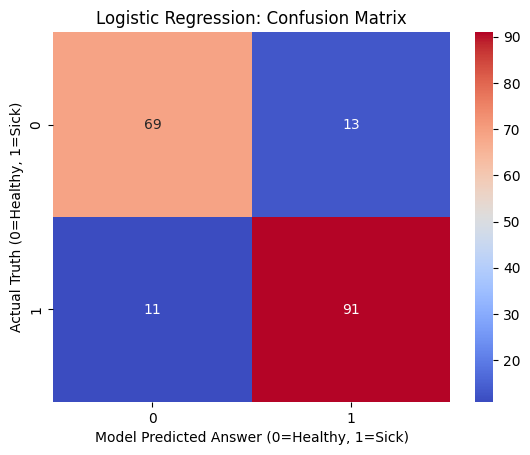

In [63]:
from sklearn.metrics import confusion_matrix

confion_matrix_log_reg = confusion_matrix(y_test,y_pred_log_reg)
display(confion_matrix_log_reg)

sns.heatmap(confion_matrix_log_reg , annot=True , cmap = 'coolwarm' )
plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Model Predicted Answer (0=Healthy, 1=Sick)')
plt.ylabel('Actual Truth (0=Healthy, 1=Sick)')
plt.show()

### 4.2.3 Precision Score :  Recall Score : F1 Score : Accuracy 

#### Accuracy Score : 
- Total Correctness = (TN+TP)/Total Patients = (TN+TP) / (TN + TP + FP + FN )
#### Recall(Sensitivity) : 
- Out of all people who actually had HeartDisease , how much of them model was able to recognize.
- ( TP ) / (TP + FN )
#### Precision : 
- Out of everyone who Model claimed were sick , how much of them were actually sick
- ( TP ) / ( TP + FP )
#### F1 Score : 
- Harmonic Average of Precision and Recall . To notice if one of them is poor and one is accurate

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_score_log_reg = accuracy_score(y_test , y_pred_log)
recall_score_log_reg = recall_score(y_test, y_pred_log)
precision_score_log_reg = precision_score(y_test, y_pred_log)
f1_score_log_reg = f1_score(y_test, y_pred_log)

print(f"Accuracy:  {accuracy_score_log_reg:.4f} (Overall correctness)")
print(f"Recall:    {recall_score_log_reg:.4f} (How many sick patients we caught)")
print(f"Precision: {precision_score_log_reg:.4f} (How much we can trust a 'Sick' alarm)")
print(f"F1-Score:  {f1_score_log_reg:.4f} (The balanced compromise)")

Accuracy:  0.8696 (Overall correctness)
Recall:    0.8922 (How many sick patients we caught)
Precision: 0.8750 (How much we can trust a 'Sick' alarm)
F1-Score:  0.8835 (The balanced compromise)
